# Movie Recommendation System

## Project Overview

This project builds a content-based movie recommendation system using the TMDB 5000 movie dataset.

The system analyzes movie metadata such as genres, keywords, cast, crew, and overview to find movies that are similar to a selected movie.

## Approach

1. Exploratory Data Analysis
2. Metadata Cleaning
3. Feature Engineering
4. Text Feature Extraction using TF-IDF
5. Cosine Similarity
6. Movie Recommendation
7. Qualitative Evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

warnings.filterwarnings("ignore")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

warnings.filterwarnings("ignore")

In [2]:
movies = pd.read_csv("../data/tmdb_5000_movies.csv")
credits = pd.read_csv("../data/tmdb_5000_credits.csv")

print("Movies dataset loaded successfully.")
print("Credits dataset loaded successfully.")

Movies dataset loaded successfully.
Credits dataset loaded successfully.


In [ ]:
#Check Dataset Shape

print("Movies dataset shape:", movies.shape)
print("Credits dataset shape:", credits.shape)

Movies dataset shape: (4803, 20)
Credits dataset shape: (4803, 4)


In [ ]:
#Inspect the Columns

print("Movies Dataset Columns:")
print(movies.columns.tolist())

print("\nCredits Dataset Columns:")
print(credits.columns.tolist())

Movies Dataset Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits Dataset Columns:
['movie_id', 'title', 'cast', 'crew']


In [5]:
#Check the dataset columns

print("Movies Dataset Columns:")
print(movies.columns.tolist())

print("\nCredits Dataset Columns:")
print(credits.columns.tolist())

Movies Dataset Columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits Dataset Columns:
['movie_id', 'title', 'cast', 'crew']


In [6]:
#Check the first 5 rows

print("Movies Dataset:")
display(movies.head())

print("\nCredits Dataset:")
display(credits.head())

Movies Dataset:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



Credits Dataset:


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [7]:
# Check missing values

print("Missing values in Movies Dataset:")
print(movies.isnull().sum())

print("\nMissing values in Credits Dataset:")
print(credits.isnull().sum())

Missing values in Movies Dataset:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

Missing values in Credits Dataset:
movie_id    0
title       0
cast        0
crew        0
dtype: int64


In [8]:
# Handle missing overview

movies["overview"] = movies["overview"].fillna("")

print("Missing values in overview after cleaning:",
      movies["overview"].isnull().sum())

Missing values in overview after cleaning: 0


Start Exploratory Data Analysis (EDA)

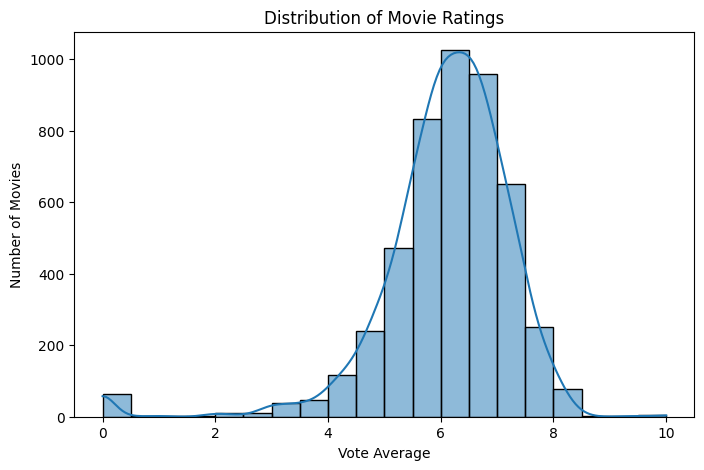

In [9]:
# EDA: Movie Rating Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    movies["vote_average"],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.show()

In [10]:
# EDA: Most Popular Movies

# EDA: Top 10 Most Popular Movies

top_popular = movies.sort_values(
    by="popularity",
    ascending=False
).head(10)

display(top_popular[["title", "popularity"]])

,title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


Visualize the Top 10 Popular Movies

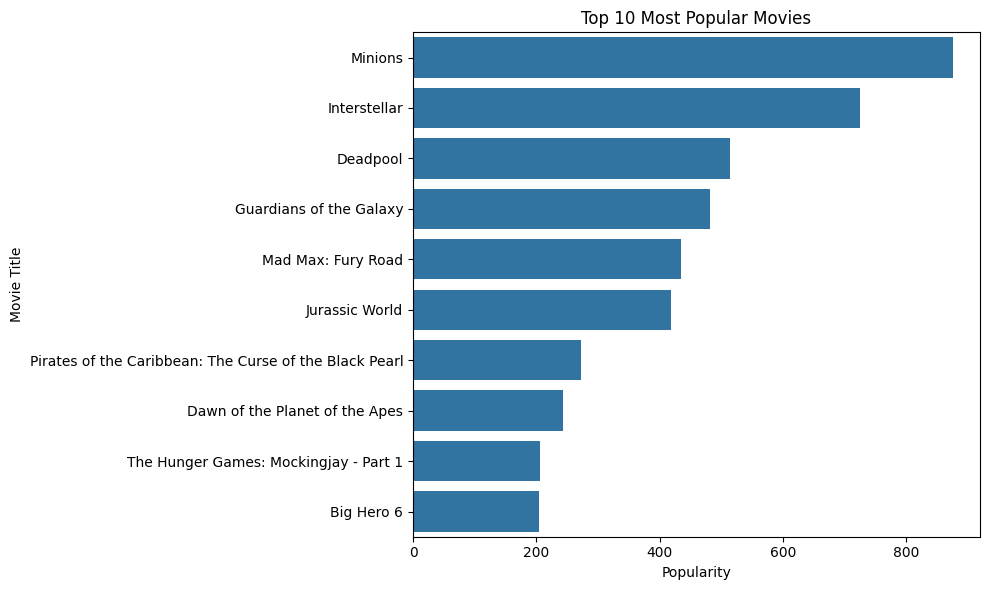

In [11]:
# EDA: Top 10 Most Popular Movies

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_popular,
    x="popularity",
    y="title"
)

plt.title("Top 10 Most Popular Movies")
plt.xlabel("Popularity")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()

EDA: Movie Ratings vs. Number of Votes

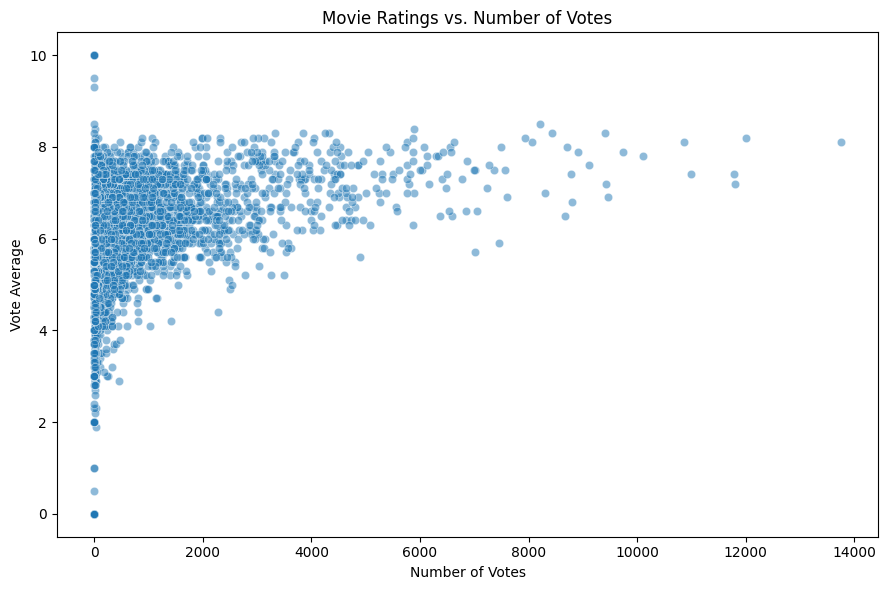

In [12]:
# EDA: Vote Count vs. Movie Rating

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=movies,
    x="vote_count",
    y="vote_average",
    alpha=0.5
)

plt.title("Movie Ratings vs. Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Vote Average")
plt.tight_layout()
plt.show()

Merge Movies and Credits

In [13]:
# Merge Movies and Credits datasets

movies = movies.merge(
    credits,
    left_on="id",
    right_on="movie_id"
)

print("Merged dataset shape:", movies.shape)
print("\nMerged dataset columns:")
print(movies.columns.tolist())

Merged dataset shape: (4803, 24)

Merged dataset columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'movie_id', 'title_y', 'cast', 'crew']


In [15]:
# Select relevant columns for recommendation

movies = movies[
    [
        "id",
        "title_x",
        "overview",
        "genres",
        "keywords",
        "cast",
        "crew"
    ]
]

# Rename title_x back to title
movies = movies.rename(columns={"title_x": "title"})

print("Selected columns:")
print(movies.columns.tolist())

print("\nDataset shape:", movies.shape)

Selected columns:
['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']

Dataset shape: (4803, 7)


In [16]:
# Inspect metadata format

print("Genres:")
print(movies["genres"].iloc[0])

print("\nKeywords:")
print(movies["keywords"].iloc[0])

print("\nCast:")
print(movies["cast"].iloc[0])

print("\nCrew:")
print(movies["crew"].iloc[0])

Genres:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Keywords:
[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]

Cast:
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id"

Create a function to extract names

In [17]:
# Function to extract names from JSON-like metadata

def extract_names(text):
    try:
        data = ast.literal_eval(text)
        return " ".join(item["name"] for item in data)
    except:
        return ""

Apply the function to genres and keywords

In [18]:
# Clean genres and keywords

movies["genres"] = movies["genres"].apply(extract_names)
movies["keywords"] = movies["keywords"].apply(extract_names)

print("Genres after cleaning:")
print(movies["genres"].iloc[0])

print("\nKeywords after cleaning:")
print(movies["keywords"].iloc[0])

Genres after cleaning:
Action Adventure Fantasy Science Fiction

Keywords after cleaning:
culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relations mind and soul 3d


Clean the Cast

In [19]:
# Function to extract top 3 cast members

def extract_cast(text):
    try:
        data = ast.literal_eval(text)
        return " ".join(item["name"] for item in data[:3])
    except:
        return ""

# Apply function to cast
movies["cast"] = movies["cast"].apply(extract_cast)

print("Cast after cleaning:")
print(movies["cast"].iloc[0])

Cast after cleaning:
Sam Worthington Zoe Saldana Sigourney Weaver


Extract the Director from Crew

In [20]:
# Function to extract director

def extract_director(text):
    try:
        data = ast.literal_eval(text)

        for item in data:
            if item["job"] == "Director":
                return item["name"]

        return ""
    except:
        return ""

# Apply function to crew
movies["crew"] = movies["crew"].apply(extract_director)

# Rename crew column to director
movies = movies.rename(columns={"crew": "director"})

print("Director after cleaning:")
print(movies["director"].iloc[0])

Director after cleaning:
James Cameron


Create the Combined tags Feature

In [21]:
# Create combined tags for recommendation

movies["tags"] = (
    movies["overview"] + " " +
    movies["genres"] + " " +
    movies["keywords"] + " " +
    movies["cast"] + " " +
    movies["director"]
)

# Convert tags to lowercase
movies["tags"] = movies["tags"].str.lower()

print("Sample tags:")
print(movies[["title", "tags"]].head())

Sample tags:
                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                                tags  
0  in the 22nd century, a paraplegic marine is di...  
1  captain barbossa, long believed to be dead, ha...  
2  a cryptic message from bond’s past sends him o...  
3  following the death of district attorney harve...  
4  john carter is a war-weary, former military ca...  


Check for missing values in our recommendation features

In [22]:
# Check missing values in recommendation features

print(movies[
    ["title", "overview", "genres", "keywords", "cast", "director", "tags"]
].isnull().sum())

title       0
overview    0
genres      0
keywords    0
cast        0
director    0
tags        0
dtype: int64


Convert Text into Numerical Features using TF-IDF

In [23]:
# TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(movies["tags"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (4803, 5000)


Calculate Cosine Similarity

In [24]:
# Calculate cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (4803, 4803)


Create the Movie Recommendation Function

In [25]:
# Movie Recommendation Function

def recommend_movies(movie_title, num_recommendations=10):
    movie_title = movie_title.lower()

    matches = movies[
        movies["title"].str.lower() == movie_title
    ]

    if matches.empty:
        print("Movie not found in the dataset.")
        return

    movie_index = matches.index[0]

    similarity_scores = list(
        enumerate(cosine_sim[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    print(f"\nRecommendations for: {movies.iloc[movie_index]['title']}\n")

    for index, score in similarity_scores[1:num_recommendations + 1]:
        print(
            f"{movies.iloc[index]['title']} "
            f"(similarity: {score:.3f})"
        )

In [26]:
# Test the recommendation system

recommend_movies("Avatar")


Recommendations for: Avatar

Aliens (similarity: 0.430)
Alien (similarity: 0.363)
Moonraker (similarity: 0.349)
Alien³ (similarity: 0.347)
Silent Running (similarity: 0.315)
Spaceballs (similarity: 0.307)
Mission to Mars (similarity: 0.284)
Lost in Space (similarity: 0.284)
Lifeforce (similarity: 0.276)
Lockout (similarity: 0.275)


In [27]:
# Test with another movie

recommend_movies("Interstellar")


Recommendations for: Interstellar

Moonraker (similarity: 0.300)
Silent Running (similarity: 0.295)
2001: A Space Odyssey (similarity: 0.280)
Lost in Space (similarity: 0.272)
Cargo (similarity: 0.269)
Armageddon (similarity: 0.266)
Planet of the Apes (similarity: 0.262)
Gravity (similarity: 0.260)
Space Pirate Captain Harlock (similarity: 0.255)
Mission to Mars (similarity: 0.254)


In [28]:
# Test with a third movie

recommend_movies("The Dark Knight Rises")


Recommendations for: The Dark Knight Rises

The Dark Knight (similarity: 0.510)
Batman Begins (similarity: 0.436)
Batman Returns (similarity: 0.433)
Batman (similarity: 0.400)
Batman Forever (similarity: 0.377)
Batman & Robin (similarity: 0.295)
Batman v Superman: Dawn of Justice (similarity: 0.262)
Batman: The Dark Knight Returns, Part 2 (similarity: 0.230)
Defendor (similarity: 0.174)
Law Abiding Citizen (similarity: 0.145)


Add the Qualitative Evaluation Section

## Qualitative Evaluation

The recommendation system was tested using sample movie queries to check whether the recommended movies were related to the input movie.

### Sample 1: Avatar
The system recommended movies such as *Aliens*, *Alien*, *Moonraker*, and *Alien³*. These movies share science-fiction and space-related characteristics with *Avatar*.

### Sample 2: Interstellar
The system recommended movies such as *Moonraker*, *Silent Running*, *2001: A Space Odyssey*, *Lost in Space*, *Gravity*, and *Mission to Mars*. These recommendations contain similar science-fiction and space-related themes.

### Sample 3: The Dark Knight Rises
The system recommended *The Dark Knight*, *Batman Begins*, *Batman Returns*, and *Batman*. These recommendations are strongly related through Batman characters and related movie metadata.

Overall, the sample queries show that the content-based recommender is able to identify movies with similar metadata using TF-IDF features and cosine similarity.

Save the TF-IDF Model

In [31]:
# Save the TF-IDF vectorizer

import joblib

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


Save the Cleaned Movie Data

In [32]:
# Save cleaned movie data

cleaned_movies = movies[
    [
        "id",
        "title",
        "overview",
        "genres",
        "keywords",
        "cast",
        "director",
        "tags"
    ]
]

cleaned_movies.to_csv(
    "../outputs/cleaned_movies.csv",
    index=False
)

print("Cleaned movie data saved successfully.")

Cleaned movie data saved successfully.
